In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import seaborn as sns
import torch

from src.data import get_electrode_df, add_metadata_features

In [12]:
sns.set_context("paper", font_scale=2)

In [10]:
all_epochs = list(Path("outputs/epochs_preprocessed").glob("*_epo.fif"))
all_results = list(Path("outputs/causal4/find_As").glob("*_results.csv"))
all_decoders = list(Path("outputs/causal4/find_As").glob("*_decoders.pt"))
all_electrode_dfs = list(Path("outputs/causal4/find_speech_responsive").glob("*_results.csv"))
outdir = "."

max_plot_rows = 15
phoneme_pair_order = ["bm", "dn", "pb"]

In [4]:
epochs = {re.findall("(EC[\d]+)_epo", str(path))[0]: mne.read_epochs(path)
          for path in all_epochs}

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC278_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
1152 matching events found
No baseline correction applied
0 projection items activated
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC270_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
432 matching events found
No baseline correction applied
0 projection items activated
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC253_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 73 columns
864 matching events found
No baseline correc

In [5]:
results = pd.concat([pd.read_csv(path) for path in all_results])

# merge in electrode metadata
electrode_df = pd.concat([pd.read_csv(path) for path in all_electrode_dfs]).set_index(["subject", "electrode_idx"])

results = results.merge(electrode_df, on=["subject", "electrode_idx"], how="left")

A_sites = results[results.A].set_index(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"])
A_sites

roc_auc  f1_macro  accuracy  \
subject electrode_idx phoneme_pair smin smax                                
EC243   102           dn           40   70      0.906  0.827375      0.83   
        87            bm           40   70      0.846  0.759193      0.76   
        101           dn           40   70      0.816  0.728564      0.73   
        87            dn           40   70      0.744  0.694847      0.70   
        115           dn           40   70      0.734  0.653258      0.66   
...                                               ...       ...       ...   
EC250   196           bm           40   70      0.696  0.606586      0.62   
        197           dn           40   70      0.696  0.614072      0.62   
        191           pb           40   70      0.696  0.673421      0.68   
        200           bm           40   70      0.684  0.648868      0.65   
        218           bm           40   70      0.682  0.650559      0.66   

                                                 A            long_name  type  \
subject electrode_idx phoneme_pair smin smax                                    
EC243   102           dn           40   70    True  InferiorParietal103  grid   
        87            bm           40   70    True   InferiorParietal88  grid   
        101           dn           40   70    True  InferiorParietal102  grid   
        87            dn           40   70    True   InferiorParietal88  grid   
        115           dn           40   70    True  InferiorParietal116  grid   
...                                            ...                  ...   ...   
EC250   196           bm           40   70    True           Inferior69  grid   
        197           dn           40   70    True           Inferior70  grid   
        191           pb           40   70    True           Inferior64  grid   
        200           bm           40   70    True           Inferior73  grid   
        218           bm           40   70    True           Inferior91  grid   

                                                           roi  \
subject electrode_idx phoneme_pair smin smax                     
EC243   102           dn           40   70         postcentral   
        87            bm           40   70         postcentral   
        101           dn           40   70         postcentral   
        87            dn           40   70         postcentral   
        115           dn           40   70          precentral   
...                                                        ...   
EC250   196           bm           40   70    superiortemporal   
        197           dn           40   70    superiortemporal   
        191           pb           40   70      middletemporal   
        200           bm           40   70    superiortemporal   
        218           bm           40   70    superiortemporal   

                                              speech_responsive  
subject electrode_idx phoneme_pair smin smax                     
EC243   102           dn           40   70                 True  
        87            bm           40   70                 True  
        101           dn           40   70                 True  
        87            dn           40   70                 True  
        115           dn           40   70                 True  
...                                                         ...  
EC250   196           bm           40   70                 True  
        197           dn           40   70                 True  
        191           pb           40   70                 True  
        200           bm           40   70                 True  
        218           bm           40   70                 True  

[167 rows x 8 columns]

In [6]:
# collect predictions on held-out extreme and intermediate trials for all decoders
dec_predictions = {}
dec_extreme_predictions = {}
for path in all_decoders:
    subject_name = re.findall("(EC[\d]+)_decoders.pt", str(path))[0]
    epochs_i = epochs[subject_name].copy()
    epochs_i.metadata = add_metadata_features(epochs_i.metadata)
    decoders = torch.load(path)
    
    for model_key, outcomes_ij in decoders["held_out_outcomes"].items():
        subject, electrode_idx, phoneme_pair, smin, smax = model_key
        if (subject, electrode_idx, phoneme_pair, smin, smax) not in A_sites.index:
            continue

        # average across folds
        outcomes_ij = outcomes_ij.groupby(["epoch_idx"]).decoder_proba.mean().reset_index()
        dec_predictions[model_key] = pd.merge(outcomes_ij, 
                                              epochs_i.metadata,
                                              left_on="epoch_idx",
                                              right_index=True)
        
    for model_key, outcomes_ij in decoders["outcomes"].items():
        subject, electrode_idx, phoneme_pair, smin, smax = model_key
        if (subject, electrode_idx, phoneme_pair, smin, smax) not in A_sites.index:
            continue

        # average across folds
        outcomes_ij = outcomes_ij.groupby("epoch_idx").decoder_proba.mean().reset_index()
        dec_extreme_predictions[model_key] = pd.merge(outcomes_ij, 
                                                      epochs_i.metadata,
                                                      left_on="epoch_idx",
                                                      right_index=True)
        
dec_predictions_df = pd.concat([
    pd.concat(dec_predictions, names=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]).droplevel(-1),
    pd.concat(dec_extreme_predictions, names=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]).droplevel(-1)
])

# merge in electrode metadata
dec_predictions_df = dec_predictions_df.merge(electrode_df, on=["subject", "electrode_idx"], how="left")

dec_predictions_df = dec_predictions_df.reset_index()
dec_predictions_df["site"] = dec_predictions_df.subject + " " + dec_predictions_df.electrode_idx.astype(str) + \
    " " + dec_predictions_df.phoneme_pair

Replacing existing metadata with 105 columns


/tmp/ipykernel_2175063/964888412.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoders = torch.load(path)


Replacing existing metadata with 105 columns


/tmp/ipykernel_2175063/964888412.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoders = torch.load(path)


Replacing existing metadata with 105 columns


...

/tmp/ipykernel_2175063/964888412.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoders = torch.load(path)


Replacing existing metadata with 105 columns


/tmp/ipykernel_2175063/964888412.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoders = torch.load(path)


Replacing existing metadata with 106 columns


/tmp/ipykernel_2175063/964888412.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoders = torch.load(path)


## Neurometric response plots

In [7]:
dec_predictions_df.columns

Index(['subject', 'electrode_idx', 'epoch_idx', 'decoder_proba', 'wav_file',
       'stim_number', 'word_end', 'non_word', 'phoneme_pair', 'morph_n',
       ...
       'label_behavior_emoji', 'feat_behavior_acoustic',
       'feat_behavior_lexical', 'feat_behavior_mismatch_left_right',
       'Unnamed: 59', 'long_name', 'type', 'roi', 'speech_responsive', 'site'],
      dtype='object', length=115)

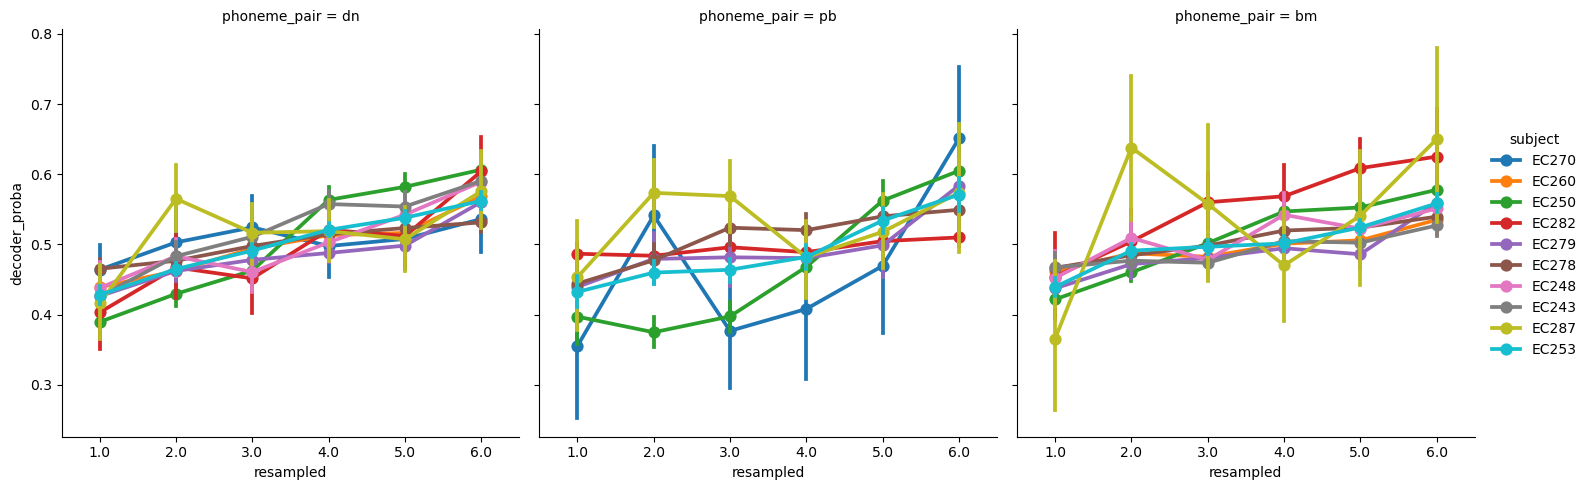

In [8]:
sns.catplot(data=dec_predictions_df, x="resampled", y="decoder_proba", kind="point", hue="subject", col="phoneme_pair")

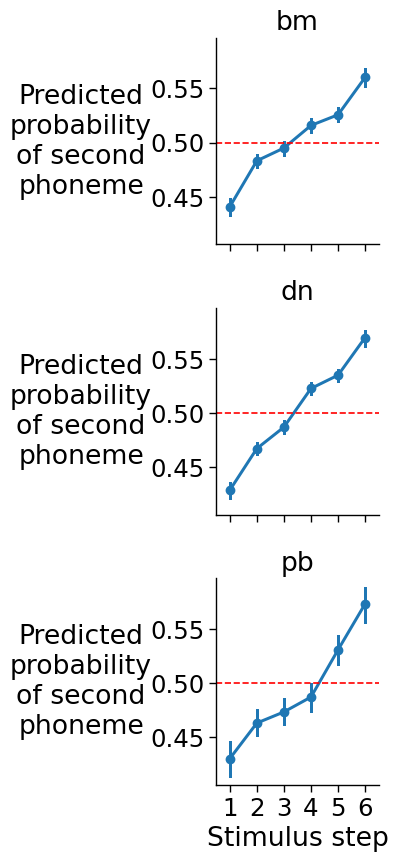

In [31]:
g = sns.catplot(data=dec_predictions_df, x="resampled", y="decoder_proba", kind="point",
            row="phoneme_pair", row_order=phoneme_pair_order, height=3)
g.set_axis_labels("Stimulus step", "Predicted\nprobability\nof second\nphoneme")
g.set_titles(row_template="{row_name}")
for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: int(val) + 1))
    ax.set_ylabel(ax.get_ylabel(), rotation=0, labelpad=50, va="center")

## Analyze individual As

In [ ]:
# order by descending ROC AUC
site_order = A_sites.groupby(["subject", "electrode_idx", "phoneme_pair"]).roc_auc.mean() \
    .sort_values(ascending=False).index.to_series() \
    .apply(lambda xs: " ".join(str(x) for x in xs)).values

n_cols = 3
if len(site_order) > max_plot_rows * n_cols:
    site_order = site_order[:max_plot_rows * n_cols]
print(f"Plotting {len(site_order)} / {len(A_sites)} sites")

g = sns.catplot(data=dec_predictions_df, x="resampled", y="decoder_proba",
                col="site", col_wrap=n_cols, col_order=site_order,
                sharey=False, sharex=True)
for ax in g.axes.flat:
    ax.axhline(0.5, color="gray", alpha=0.5, linestyle="--")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Stimulus step")
    phoneme_pair = ax.get_title().split(" ")[-1]
    ax.set_ylabel(f"Decoder $P(\\text{{{phoneme_pair[1]}}} \\mid A)$")

In [ ]:
# Spearman correlation between decoder output and stimulus step on intermediate trials
held_out_spearman = dec_predictions_df[~dec_predictions_df.resampled.isin((1, 6))] \
    .groupby(["subject", "electrode_idx", "phoneme_pair"]) \
    .apply(lambda xs: pd.Series(spearmanr(xs.decoder_proba, xs.resampled), index=["spearmanr", "pval"]))

In [ ]:
g = sns.relplot(data=held_out_spearman.join(A_sites), x="spearmanr", y="roc_auc",
                hue="subject", col="phoneme_pair", height=4)
g.fig.suptitle("Relationship between performance on extremes (y)\nand stimulus-lockedness (x) of decoder output\non intermediate trials")
g.tight_layout()

def add_corr(data, **kwargs):
    """Add correlation coefficient to the plot."""
    corr = data[["spearmanr", "roc_auc"]].corr().iloc[0, 1]
    ax = plt.gca()
    ax.text(0.05, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
            fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
    
    # draw a line of best fit
    sns.regplot(data=data, x="spearmanr", y="roc_auc", ax=ax, scatter=False, **{**kwargs, "color": "gray"})
    return corr
g.map_dataframe(add_corr)

## Analyze A relationships

In [ ]:
# take one random pair of electrodes from each phoneme pair
plot_sites = A_sites.groupby(["subject", "phoneme_pair"]).apply(
    lambda x: x.sample(2) if len(x) > 1 else x.iloc[:0])

n_plots = len(plot_sites) / 2
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))
n_rows = min(n_rows, max_plot_rows)

f, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
for ax, ((subject, phoneme_pair), rows) in zip(axs.flat, plot_sites.groupby(["subject", "phoneme_pair"])):
    _, _, x_subject, x_electrode_idx, x_phoneme_pair, _, _ = rows.index[0]
    _, _, y_subject, y_electrode_idx, y_phoneme_pair, _, _ = rows.index[1]

    x_preds = dec_predictions_df[
        (dec_predictions_df.subject == x_subject) &
        (dec_predictions_df.electrode_idx == x_electrode_idx) &
        (dec_predictions_df.phoneme_pair == x_phoneme_pair)
    ]
    y_preds = dec_predictions_df[
        (dec_predictions_df.subject == y_subject) &
        (dec_predictions_df.electrode_idx == y_electrode_idx) &
        (dec_predictions_df.phoneme_pair == y_phoneme_pair)
    ]

    plot_df = x_preds.set_index(["epoch_idx"]).decoder_proba.rename("x_proba").to_frame()
    plot_df = plot_df.merge(y_preds.set_index(["epoch_idx"]).decoder_proba.rename("y_proba").to_frame(), left_index=True, right_index=True)
    
    sns.regplot(data=plot_df, x="x_proba", y="y_proba", ax=ax)
    ax.set_title(f"{x_subject} {x_electrode_idx} vs. {y_subject} {y_electrode_idx} ({phoneme_pair})")

In [ ]:
corr_results = []
for (subject, phoneme_pair), rows in dec_predictions_df[~dec_predictions_df.resampled.isin((1, 6))].groupby(["subject", "phoneme_pair"]):
    rows = rows.set_index(["epoch_idx", "electrode_idx"]).decoder_proba.unstack()
    if rows.shape[1] < 2:
        continue
    corr = rows.corr()
    corr_results.append((subject, phoneme_pair, rows, corr))

In [ ]:
# # counterfactual: correlate decoders from DISTINCT subjects.
# # we'll do this by aligning trials by stimulus resampled value, and shuffling within that

# # resample/subsample each subject's trials to this target count
# target_num_trials = int(dec_predictions_df.groupby(["subject", "phoneme_pair", "electrode_idx", "resampled"]).size().median())
# study_phoneme_pair = "dn"

# aligned_predictions = {}
# for (subject, electrode_idx), rows in dec_predictions_df.query("phoneme_pair == @study_phoneme_pair").groupby(["subject", "electrode_idx"],):
#     # resample to a balanced number of trials per resampled value
#     rows = rows.groupby("resampled").apply(
#         lambda xs: xs.sample(target_num_trials) if len(xs) > target_num_trials else xs.sample(target_num_trials, replace=True),
#         include_groups=False).sort_index()
#     aligned_predictions[subject, electrode_idx] = rows.decoder_proba.reset_index(drop=True)

In [ ]:
# aligned_predictions_df = pd.concat([p.rename(f"{subject} {electrode_idx}").to_frame()
#                                      for (subject, electrode_idx), p in aligned_predictions.items()],
#                                     names=["subject", "electrode_idx"], axis=1)
# aligned_predictions_df.corr().reset_index().melt(id_vars=["index"]).query("index != variable").sort_values("value", ascending=False).head(10)
# # TODO do something with this

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(corr_results) / n_cols))
f, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
vmin = min([result.min().min() for _, _, _, result in corr_results])
vmax = max([result.max().max() for _, _, _, result in corr_results])
for ax, (subject, phoneme_pair, rows, corr) in zip(axs.flatten(), corr_results):
    sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.8}, vmin=vmin, vmax=vmax)
    ax.set_title(f"{subject} - {phoneme_pair}")

f.suptitle("Correlation between decoder outputs within-subject across sites\non intermediate trials")
f.tight_layout()

### Relationship between A-site distance and prediction similarity

In [ ]:
distance_prediction_results = []

for subject, phoneme_pair, rows, corr in corr_results:
    # retrieve augmented electrode df with coordinates
    # TODO re-run the whole pipeline with this
    electrode_df_i = get_electrode_df(subject)
    for e1_idx, e2_idx in zip(*np.tril_indices(corr.shape[0], k=-1, m=corr.shape[1])):
        e1 = corr.index[e1_idx]
        e2 = corr.index[e2_idx]

        e1_pos = electrode_df_i.loc[e1, ["x", "y", "z"]].values
        e2_pos = electrode_df_i.loc[e2, ["x", "y", "z"]].values
        dist = np.linalg.norm(e1_pos - e2_pos)

        distance_prediction_results.append({
            "subject": subject,
            "phoneme_pair": phoneme_pair,
            "e1": e1,
            "e2": e2,
            "distance": dist,
            "spearmanr": corr.loc[e1, e2],
        })

In [ ]:
distance_prediction_df = pd.DataFrame(distance_prediction_results)
distance_prediction_df[["distance", "spearmanr"]].corr()

In [ ]:
g = sns.lmplot(data=distance_prediction_df, x="distance", y="spearmanr",
               line_kws={"color": "gray"}, scatter_kws={"alpha": 0.5})
g.fig.suptitle("Electrode distance vs. decoder output correlation")
g.tight_layout()